# py-dcHiC tutorial — A/B compartments & differential analysis in Python

A copy-pastable tour of the public API. Install from source (`pip install git+https://github.com/ChrisMao0325/py-dcHiC.git`), then:

In [1]:
import os, json, subprocess, sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, '/large_storage/zhoulab/shengmao/py-dcHiC')
sys.path.insert(0, '/large_storage/zhoulab/shengmao/py-dcHiC/tests')
PORT = '/large_storage/zhoulab/shengmao/py-dcHiC'
R_ENV = os.environ.get("R_TEST_ENV", "/home/shengmao/.local/share/mamba/envs/dchic")
RSCRIPT = f"{R_ENV}/bin/Rscript"
FIX = os.path.join(PORT, "data", "fixture_dchic.json")

import pydchic
print('pydchic', pydchic.__version__)

pydchic 0.1.0


## 1. Compartment calling from a contact matrix

`call_compartments` turns raw intra-chromosomal contacts into GC-oriented compartment PCs:
observed/expected → correlation → correlation-of-correlation → eigendecomposition →
projection → GC sign-orientation. The A/B score is PC1.

compartment PC matrix: (200, 2) | kept bins: 200


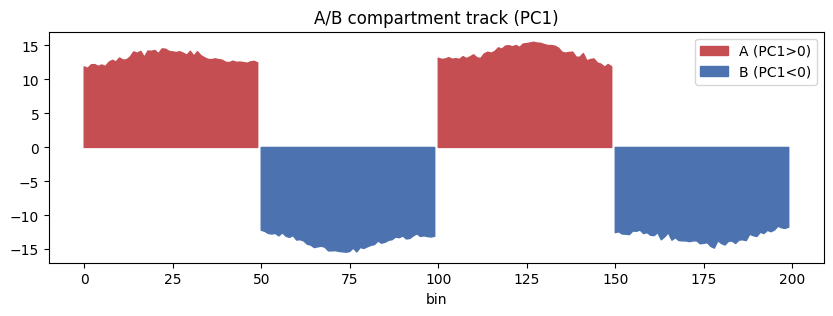

In [2]:
fix = json.load(open(FIX)); a = fix["stageA"]
pc, keep = pydchic.call_compartments(
    np.array(a["a_idx"]), np.array(a["b_idx"]), np.array(a["weight"], float),
    np.array(a["pos"], float), np.array(a["gcc"], float),
    int(a["n_bins"]), int(a["resolution"]), n_pcs=2)
print("compartment PC matrix:", pc.shape, "| kept bins:", int(keep.sum()))
plt.figure(figsize=(10,3)); s = pc[:,0]
plt.fill_between(range(len(s)), s, where=s>=0, color="#c44e52", label="A (PC1>0)")
plt.fill_between(range(len(s)), s, where=s<0, color="#4c72b0", label="B (PC1<0)")
plt.title("A/B compartment track (PC1)"); plt.xlabel("bin"); plt.legend(); plt.show()

## 2. Lower-level functional API (mirrors the R functions one-to-one)

In [3]:
from pydchic.compartment import observed_over_expected, ijk2mat, compartment_pca, orient_pc
A,B,oe = observed_over_expected(np.array(a["a_idx"]),np.array(a["b_idx"]),np.array(a["weight"],float),
                                np.array(a["pos"],float),int(a["n_bins"]),int(a["resolution"]))
M = ijk2mat(A,B,oe,int(a["n_bins"]))
pc_raw,_ = compartment_pca(M, n_pcs=2)
pc_or = orient_pc(pc_raw, np.array(a["gcc"])[M.sum(1)>=3])
print("O/E matrix:", M.shape, "| PC after orientation == call_compartments:",
      np.allclose(pc_or, pc))

O/E matrix: (200, 200) | PC after orientation == call_compartments: True


## 3. Differential compartment analysis across conditions

`quantile_normalize_by_condition` + `differential_compartments` reproduce dcHiC's `analyze`
step: per-condition quantile normalization, condition means, a robust-covariance Mahalanobis
distance scaled by the squared cross-condition range, a chi-square p-value, and BH adjustment.

conditions: ['CN', 'ES', 'NPC']
most differential bins (padj): [0. 0. 0. 0. 0.]


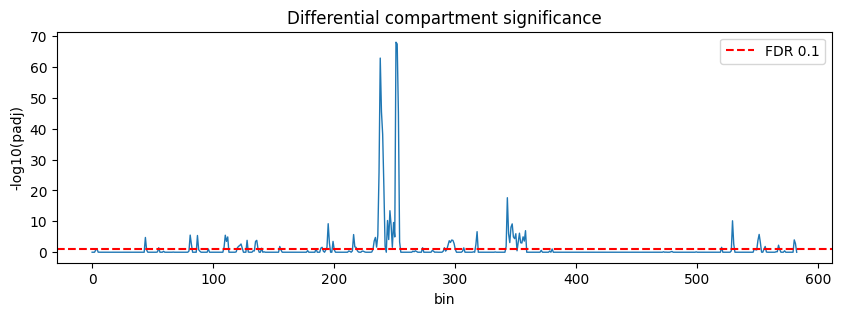

In [4]:
b = fix["stageB"]
pc_raw = np.array(b["pc_raw"], float); conditions = b["conditions"]
qn = pydchic.quantile_normalize_by_condition(pc_raw, conditions)
res = pydchic.differential_compartments(qn, conditions)
import numpy as np
order = np.argsort(res["padj"])
print("conditions:", sorted(set(conditions)))
print("most differential bins (padj):", np.round(res["padj"][order][:5], 4))
plt.figure(figsize=(10,3)); plt.plot(-np.log10(np.clip(res["padj"],1e-300,1)), lw=1)
plt.axhline(-np.log10(0.1), color="r", ls="--", label="FDR 0.1")
plt.title("Differential compartment significance"); plt.xlabel("bin"); plt.ylabel("-log10(padj)"); plt.legend(); plt.show()

## 4. Class API (method chaining)

In [5]:
from pydchic import dcHiC
model = dcHiC(resolution=int(a["resolution"]))
model.differential(pc_raw, conditions)
print(model.differential_.sort_values("padj").head())

             pval          padj  sample_maha
251  1.599725e-71  9.326398e-69   326.027419
252  1.215204e-70  3.542320e-68   321.972089
238  6.559927e-66  1.274812e-63   300.179273
239  2.066426e-48  3.011815e-46   219.596528
253  5.784706e-48  6.744967e-46   217.537734


## Pitfalls (parity notes)

- **PC sign is arbitrary** — dcHiC orients PC1 by GC content; absolute sign is not meaningful.
- **Columns must be grouped by condition** for the differential step.
- The robust covariance (`MinCovDet`) and BH (vs dcHiC's `IHW`) mean differential **p-values
  match in ranking**, not element-wise — see `MATH.md`.